# Example-05: RPCA

In [1]:
# Import

import numpy
import torch

import sys
sys.path.append('..')

from harmonica.util import data_load
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

True


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

In [3]:
# https://arxiv.org/abs/0912.3599
# RPCA can be performed with rpca classmethod
# Single matrix should be passed on input (this can be a full TbT matrix or a Hankel matrix of a signal)

# Separate 'grained' noise using RPCA

# Generate original low rank matrix

n = 100
k = 3
m = 40
X = numpy.hstack([numpy.ones((n, m)) * (i + 1) * 10 for i in range(k)])
print(X.shape)
print(X)
print(torch.linalg.matrix_rank(torch.tensor(X)))

# Generate matrix with missing values (change fraction of missing values to observe convergence)

Y = numpy.copy(X)
Y[numpy.random.rand(*Y.shape) < 0.1] = 0.0
print(Y.shape)
print(Y)
print(torch.linalg.matrix_rank(torch.tensor(Y)))

# Perform RPCA (change the number of iterations and/or the tolerance factor to observe convergence)

count, error, L, S = Filter.rpca(torch.tensor(Y, dtype=dtype, device=device), limit=8912, factor=1.0E-12, cpu=True)

# Number of iterations and final error

print(count)
print(error)

# 'Cleaned' matrix rank

print(torch.linalg.matrix_rank(L))
print(L.cpu().numpy())

# Maximum element-wise error

print(numpy.max(numpy.abs((X - L.cpu().numpy()))))

(100, 120)
[[10. 10. 10. ... 30. 30. 30.]
 [10. 10. 10. ... 30. 30. 30.]
 [10. 10. 10. ... 30. 30. 30.]
 ...
 [10. 10. 10. ... 30. 30. 30.]
 [10. 10. 10. ... 30. 30. 30.]
 [10. 10. 10. ... 30. 30. 30.]]
tensor(1)
(100, 120)
[[10. 10. 10. ... 30. 30. 30.]
 [10. 10. 10. ...  0. 30. 30.]
 [10. 10. 10. ... 30. 30. 30.]
 ...
 [10. 10. 10. ... 30. 30. 30.]
 [10. 10. 10. ... 30. 30. 30.]
 [10. 10. 10. ... 30. 30. 30.]]
tensor(100)
296
tensor(1.527428311139e-09, dtype=torch.float64)
tensor(1)
[[10. 10. 10. ... 30. 30. 30.]
 [10. 10. 10. ... 30. 30. 30.]
 [10. 10. 10. ... 30. 30. 30.]
 ...
 [10. 10. 10. ... 30. 30. 30.]
 [10. 10. 10. ... 30. 30. 30.]
 [10. 10. 10. ... 30. 30. 30.]]
1.609272715086263e-10


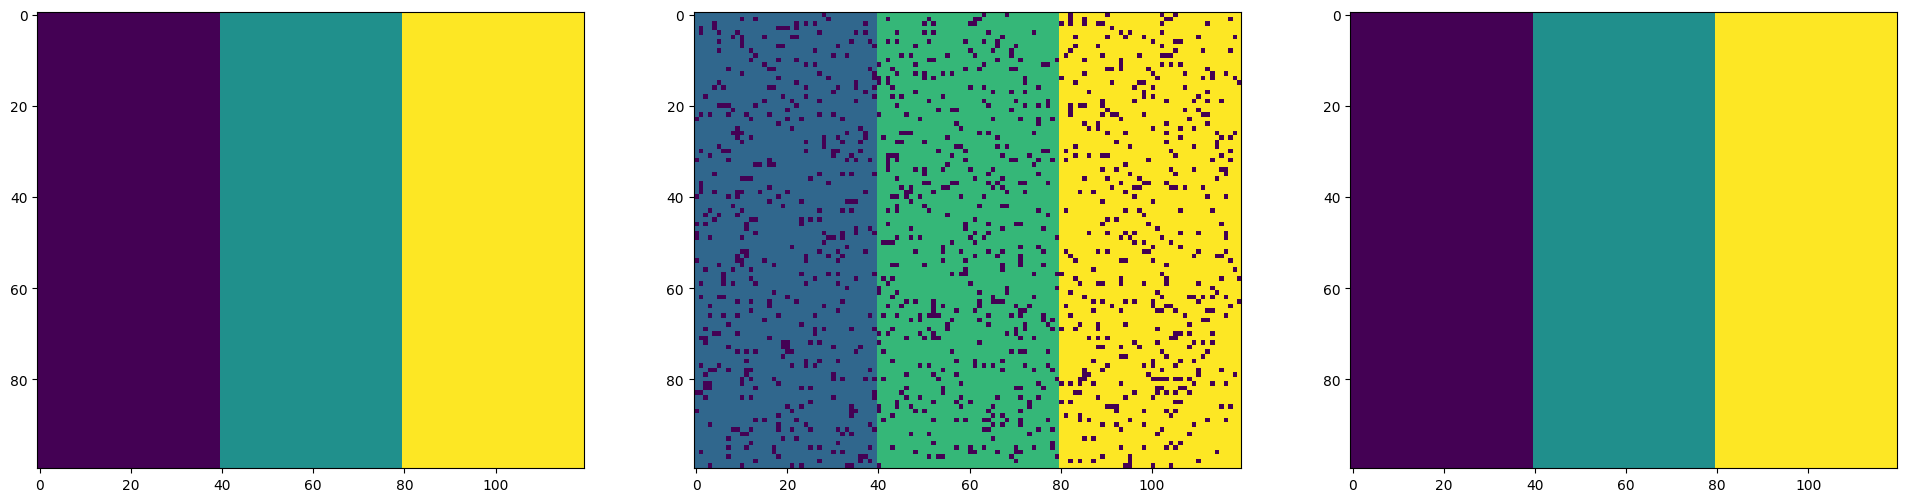

In [4]:
# Plot matrices

plt.figure(figsize=(3*8, 3*8))
ax = plt.subplot(331)
ax.imshow(X)
ax = plt.subplot(332)
ax.imshow(Y)
ax = plt.subplot(333)
ax.imshow(L)
plt.show()